In [1]:
# Real scalar boson star or oscillaton example
# see further details in https://github.com/GRChombo/engrenage/wiki/Running-the-oscillaton-example

# restart the kernel to clear past work
# (can also do this manually from the Kernel options above)
# Commented out these 2 lines
from IPython.core.display import HTML
HTML("<script>Jupyter.notebook.kernel.restart()</script>")

In [2]:
import sys
print(sys.executable)

import os
os.getcwd()

import gc

/apps/leuven/rocky8/skylake/2021a/software/Python/3.9.5-GCCcore-10.3.0/bin/python


In [3]:
# load the required python modules
import numpy as np
from scipy.interpolate import interp1d
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
import time
import random
import sys
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline

# Modified Gravity
#sys.path.append('/Users/serdaryildiz/Desktop/GRSerdar/engrenage/SGB_Oscillons/source')
#

#sys.path.append('/Users/serdaryildiz/Desktop/0scillonsFiles/Feb26')

# New cluster path
sys.path.append('/user/leuven/384/vsc38419/0scillons/February26Oscillons/Feb26')


from core.grid import Grid
from core.rhsevolution_MG import *
from core.spacing import *
from core.display import * 
from core.statevector import *
from matter.scalarmatter_MG import *

from bssn.oscillondiagnostic import (get_oscillon_diagnostic,
                                     plot_density_profiles_at_times,
                                     plot_paper_diagnostics)


# This is the one where we solve the constraints with solver in stead of importing data
from initialdata.ModifiedGravityInitialConditions import *

# In these two we import tabulated oscillon initial data
#from initialdata.ModifiedGravityInitialConditions2 import *
#from initialdata.oscillatoninitialconditions_MG import *

from backgrounds.sphericalbackground import *
from bssn.constraintsdiagnostic import *
from bssn.ahfinder import *

In [4]:
####################################################
# CHOOSE SIMULATION PARAMETERS
####################################################

#Mass of scalar field
scalar_mu = 1

# Extra parameter in scalar potential
#selfinteraction = 0.1

#Modified Gravity parameters
"""
lambda_GB = 0.001 # Coupling constant
a = 0.2 # modified gauge parameter
b= 0.4 # # modified gauge parameter
"""
lambda_GB = 0
a = 0
b = 0
chi0 = 0.15  #S function that slowly turns off the MG terms when getting closer to singularity

# The other option to choose from is 'Linear'
coupling = 'quadratic'

####################################################
# DATA FROM PAPER 
####################################################
TABLE_I = {
    0.04: dict(phi=-6.03334e-2, dphi=2.20256e-2, H=1.55744e-2),
    0.05: dict(phi=-7.36454e-2, dphi=2.72499e-2, H=1.92686e-2),
    0.06: dict(phi=-8.64102e-2, dphi=3.23761e-2, H=2.28934e-2),
    0.07: dict(phi=-9.86792e-2, dphi=3.74094e-2, H=2.64525e-2),
    0.08: dict(phi=-1.10495e-1, dphi=4.23540e-2, H=2.99488e-2),
    0.09: dict(phi=-1.21893e-1, dphi=4.72136e-2, H=3.33851e-2),
    0.10: dict(phi=-1.32906e-1, dphi=5.19917e-2, H=3.67637e-2),
}

#Self interaction value from the cosmological potential
selfinteraction = 0.08

# Initial values scalar field and momentum scalar field
u_val = TABLE_I[selfinteraction]['phi']
v_val = TABLE_I[selfinteraction]['dphi']

# PERTURBATION
perturbation_amplitude = -2e-3 # set to zero for no perturbation
perturbation_width = 3

# Grouping parameters
ppp = (lambda_GB, a, b, chi0, coupling)

# ── Low Resolution ──
T = 800
num_points_t = 1000
dt = T / num_points_t
t = np.linspace(0, T - dt, num_points_t)

perturbation = -2e-2
width = 3

In [5]:
####################################################
# CHOOSE SIMULATION RESOLUTION
####################################################

my_matter = ScalarMatter(scalar_mu, selfinteraction)
my_state_vector = StateVector(my_matter)

"""
# HIGHER RESOLUTION
r_max = 96.0 # outer edge of the grid (including ghosts)
min_dr = 1 / 16
max_dr = 2
"""


# LOWER RESOLUTION
r_max = 150 # outer edge of the grid (including ghosts)
min_dr_LR = 1 / 4
min_dr_MR = 1 / 8
min_dr_HR = 1 / 16

max_dr = 2


"""
# LOWER RESOLUTION
r_max = 64
min_dr = 1 / 4
max_dr = 2
"""

# CubicSpacing
params_LR = CubicSpacing.get_parameters(r_max, min_dr_LR, max_dr)
params_MR = CubicSpacing.get_parameters(r_max, min_dr_MR, max_dr)
params_HR = CubicSpacing.get_parameters(r_max, min_dr_HR, max_dr)

spacing_LR = CubicSpacing(**params_LR)
spacing_MR = CubicSpacing(**params_MR)
spacing_HR = CubicSpacing(**params_HR)

# Grid
grid_LR = Grid(spacing_LR, my_state_vector)
grid_MR = Grid(spacing_MR, my_state_vector)
grid_HR = Grid(spacing_HR, my_state_vector)

r_LR = grid_LR.r
r_MR = grid_MR.r
r_HR = grid_HR.r

num_points_LR = r_LR.size
num_points_MR = r_MR.size
num_points_HR = r_HR.size

print(num_points_LR)
print(num_points_MR)
print(num_points_HR)

background_LR = FlatSphericalBackground(r_LR)
background_MR = FlatSphericalBackground(r_MR)
background_HR = FlatSphericalBackground(r_HR)

184
204
216


In [6]:
NOTEBOOK_DIR = "/user/leuven/384/vsc38419/0scillons/February26Oscillons/Feb26/Notebooks"
DATA_DIR = os.path.join(NOTEBOOK_DIR, "convergence_data")
os.makedirs(DATA_DIR, exist_ok=True)

In [11]:


initial_state_LR = get_initial_state(
    grid_LR, background_LR, (lambda_GB, a, b, chi0, coupling),
    my_matter, perturbation, width, scalar_mu, u_val, v_val)

with tqdm(total=1000, unit="‰") as progress_bar:
    dense_solution_LR = solve_ivp(
        get_rhs, [0, T], initial_state_LR,
        args=(grid_LR, background_LR, my_matter, progress_bar,
              [0, T/1000], a, b, lambda_GB, coupling),
        max_step=0.4 * min_dr_LR,
        method='RK45',
        dense_output=True)

solution_LR = dense_solution_LR.sol(t).T

np.save(os.path.join(DATA_DIR, "solution_LR.npy"), solution_LR)
np.save(os.path.join(DATA_DIR, "t.npy"), t)
print(f"Saved LR solution: shape {solution_LR.shape}")

del dense_solution_LR, solution_LR, initial_state_LR
gc.collect()

error is:  0.009372858044225964  after iter:  2


  0%|          | 0/1000 [00:00<?, ?‰/s]

Saved LR solution: shape (1000, 2576)


17

In [12]:
# ── Medium Resolution ──
initial_state_MR = get_initial_state(
    grid_MR, background_MR, (lambda_GB, a, b, chi0, coupling),
    my_matter, perturbation, width, scalar_mu, u_val, v_val)

with tqdm(total=1000, unit="‰") as progress_bar:
    dense_solution_MR = solve_ivp(
        get_rhs, [0, T], initial_state_MR,
        args=(grid_MR, background_MR, my_matter, progress_bar,
              [0, T/1000], a, b, lambda_GB, coupling),
        max_step=0.4 * min_dr_MR,
        method='RK45',
        dense_output=True)

solution_MR = dense_solution_MR.sol(t).T

np.save(os.path.join(DATA_DIR, "solution_MR.npy"), solution_MR)
print(f"Saved MR solution: shape {solution_MR.shape}")

del dense_solution_MR, solution_MR, initial_state_MR
gc.collect()

error is:  0.009547354084340931  after iter:  9


  0%|          | 0/1000 [00:00<?, ?‰/s]

Saved MR solution: shape (1000, 2856)


35

In [7]:
# ── High Resolution ──
initial_state_HR = get_initial_state(
    grid_HR, background_HR, (lambda_GB, a, b, chi0, coupling),
    my_matter, perturbation, width, scalar_mu, u_val, v_val)

with tqdm(total=1000, unit="‰") as progress_bar:
    dense_solution_HR = solve_ivp(
        get_rhs, [0, T], initial_state_HR,
        args=(grid_HR, background_HR, my_matter, progress_bar,
              [0, T/1000], a, b, lambda_GB, coupling),
        max_step=0.4 * min_dr_HR,
        method='RK45',
        dense_output=True)

solution_HR = dense_solution_HR.sol(t).T

np.save(os.path.join(DATA_DIR, "solution_HR.npy"), solution_HR)
print(f"Saved HR solution: shape {solution_HR.shape}")

del dense_solution_HR, solution_HR, initial_state_HR
gc.collect()

error is:  0.00975394413816646  after iter:  14


  0%|          | 0/1000 [00:00<?, ?‰/s]

Saved HR solution: shape (1000, 3024)


17

In [7]:
from bssn.oscillondiagnostic import (
    get_oscillon_diagnostic,
    plot_paper_diagnostics,
    plot_density_profiles_at_times,
    plot_density_contrast_profiles,
    plot_density_contrast_vs_lna,
    plot_central_density_vs_lna,
    plot_density_contrast_comparison,
    plot_hubble_vs_lna,
)

import gc

params = (lambda_GB, a, b, chi0, coupling)
r_max_diag = 100.0
t = np.load(os.path.join(DATA_DIR, "t.npy"))

# Load one at a time to keep memory low
sol_LR = np.load(os.path.join(DATA_DIR, "solution_LR.npy"))
print(f"Loaded LR: {sol_LR.shape}")
osc_LR = get_oscillon_diagnostic(sol_LR, t, grid_LR, background_LR,
                                  my_matter, params, surface_threshold=0.05,
                                  r_max_diag=r_max_diag)
del sol_LR; gc.collect()

sol_MR = np.load(os.path.join(DATA_DIR, "solution_MR.npy"))
print(f"Loaded MR: {sol_MR.shape}")
osc_MR = get_oscillon_diagnostic(sol_MR, t, grid_MR, background_MR,
                                  my_matter, params, surface_threshold=0.05,
                                  r_max_diag=r_max_diag)
del sol_MR; gc.collect()

sol_HR = np.load(os.path.join(DATA_DIR, "solution_HR.npy"))
print(f"Loaded HR: {sol_HR.shape}")
osc_HR = get_oscillon_diagnostic(sol_HR, t, grid_HR, background_HR,
                                  my_matter, params, surface_threshold=0.05,
                                  r_max_diag=r_max_diag)
del sol_HR; gc.collect()

print("\nResolution ratio  h_LR/h_MR =", min_dr_LR/min_dr_MR,
      "  h_MR/h_HR =", min_dr_MR/min_dr_HR)
print("Available keys:", list(osc_HR.keys()))

Loaded LR: (1000, 2576)
Loaded MR: (1000, 2856)
Loaded HR: (1000, 3024)

Resolution ratio  h_LR/h_MR = 2.0   h_MR/h_HR = 2.0
Available keys: ['t', 'r', 'rho', 'rho_c', 'rho_bar', 'delta_c', 'delta_rho', 'a', 'ln_a', 'K_avg', 'M', 'V_proper', 'R', 'C', 'u_c', 'u_bar', 'Asq_c']


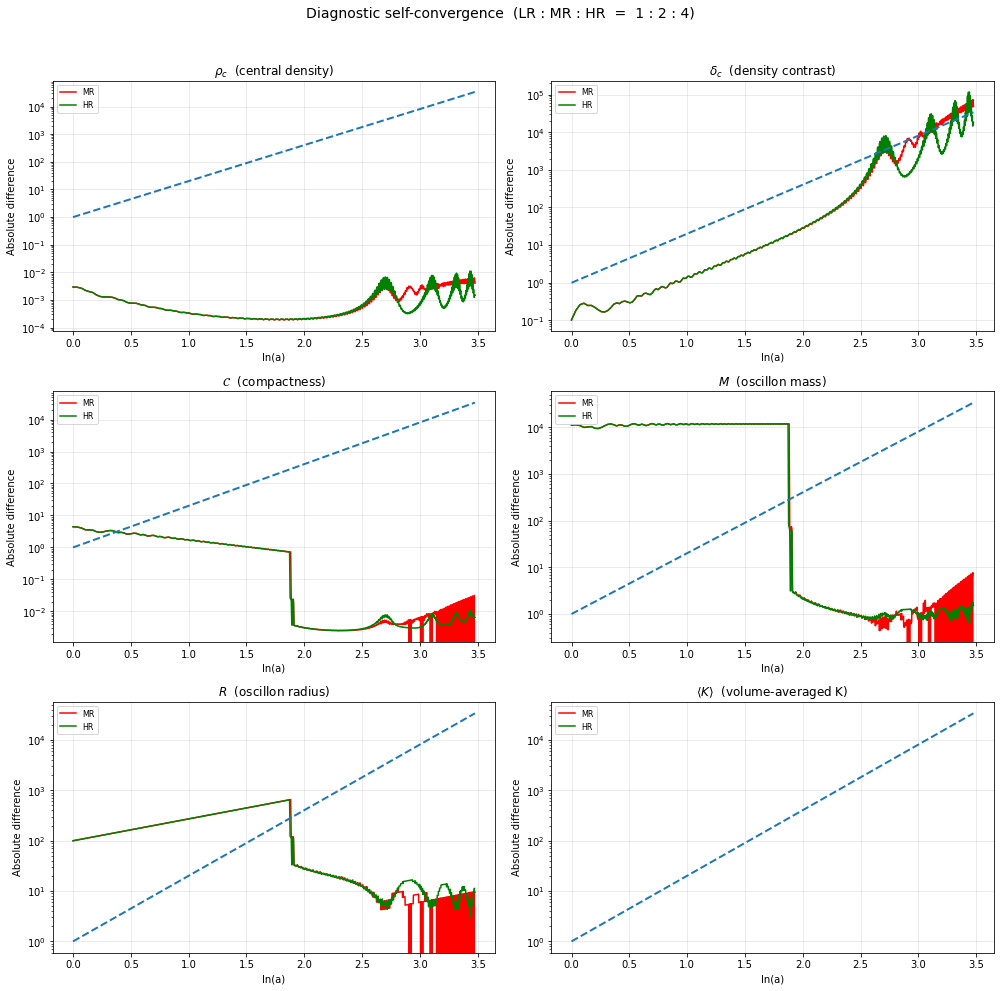

In [26]:
# ── Paper Fig. 4 style:  δ_c and ρ_c  vs  ln(a) ──
# Uses HR data; the a³ scaling at late times is shown as a dashed reference line.

ln_a    = osc_HR["ln_a"]
delta_c = osc_HR["delta_c"]
rho_c   = osc_HR["rho_c"]
rho_bar = osc_HR["rho_bar"]
a_arr   = osc_HR["a"]

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(7, 9), sharex=True)

# ────────────────────────────────────────────────────────────
# Top panel:  log₁₀(δ_c) vs ln(a)   [paper Fig. 4 top row]
# ────────────────────────────────────────────────────────────
pos_dc    = delta_c > 0
log_dc    = np.full_like(delta_c, np.nan)
log_dc[pos_dc] = np.log10(delta_c[pos_dc])

ax_top.plot(ln_a, log_dc, 'b-', lw=1.5,
            label=rf'$\mu = {selfinteraction}\,M_{{\rm Pl}}$')

# a³ reference line:  δ_c ∝ a³ at late times because ρ_c ≈ const
# while ρ̄ ∝ a⁻³ in a matter-dominated background.
# On a log₁₀(δ_c) vs ln(a) plot this is a straight line with
# slope  3 / ln(10).
# Anchor the line at  ~90 % of the simulation time.
t_anchor = int(0.9 * len(t))
if pos_dc[t_anchor]:
    slope = 3.0 / np.log(10)
    offset = log_dc[t_anchor] - slope * ln_a[t_anchor]
    a3_ref = slope * ln_a + offset
    ax_top.plot(ln_a, a3_ref, 'k--', lw=1.2, alpha=0.6,
                label=r'$\propto a^3$')

ax_top.set_ylabel(r'$\log_{10}(\delta_c)$', fontsize=13)
ax_top.set_title(r'Density contrast  $\delta_c \equiv \rho_c/\bar\rho - 1$',
                 fontsize=13)
ax_top.legend(fontsize=11, loc='upper left')
ax_top.grid(True, alpha=0.3)

# ────────────────────────────────────────────────────────────
# Bottom panel:  log₁₀(ρ_c) vs ln(a)  [paper Fig. 4 bottom row]
# ────────────────────────────────────────────────────────────
pos_rc = rho_c > 0
log_rc = np.full_like(rho_c, np.nan)
log_rc[pos_rc] = np.log10(rho_c[pos_rc])

pos_rb = rho_bar > 0
log_rb = np.full_like(rho_bar, np.nan)
log_rb[pos_rb] = np.log10(rho_bar[pos_rb])

ax_bot.plot(ln_a, log_rc, 'b-',  lw=1.5, label=r'$\rho_c$')
ax_bot.plot(ln_a, log_rb, 'b--', lw=1.0, alpha=0.6,
            label=r'$\bar{\rho}$')

ax_bot.set_xlabel(r'$\ln(a)$', fontsize=13)
ax_bot.set_ylabel(r'$\log_{10}(\rho_c \;[m^2 M_{\rm Pl}^2])$', fontsize=13)
ax_bot.set_title(r'Central density  $\rho_c$', fontsize=13)
ax_bot.legend(fontsize=11)
ax_bot.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

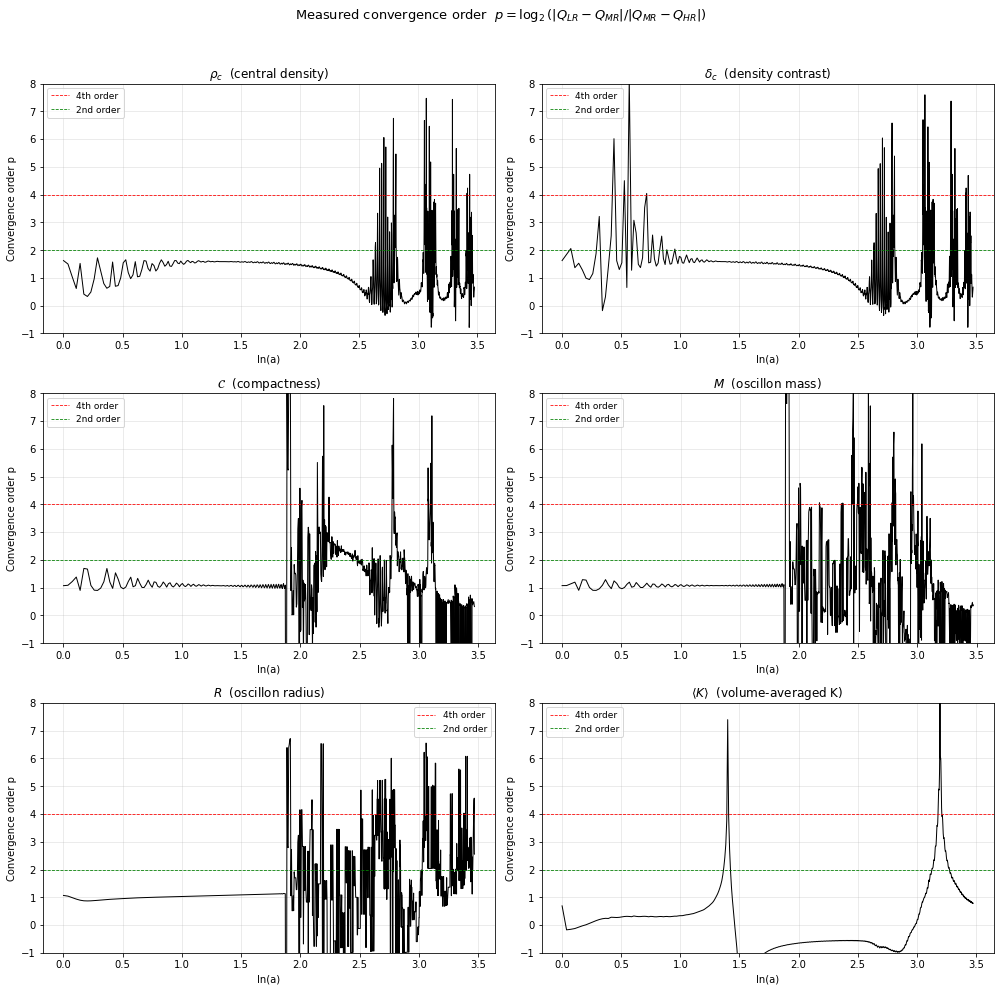

In [14]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.ravel()

for ax_idx, (key, label) in enumerate(diag_keys.items()):
    diff_LM = np.abs(osc_LR[key] - osc_MR[key])
    diff_MH = np.abs(osc_MR[key] - osc_HR[key])

    with np.errstate(divide='ignore', invalid='ignore'):
        order = np.log2(diff_LM / diff_MH)

    valid = (diff_MH > 1e-14) & np.isfinite(order)

    ax = axes[ax_idx]
    ax.plot(osc_LR['ln_a'][valid], order[valid], 'k-', lw=1.0)
    ax.axhline(4, color='r', ls='--', lw=0.8, label='4th order')
    ax.axhline(2, color='g', ls='--', lw=0.8, label='2nd order')
    ax.set_xlabel('ln(a)')
    ax.set_ylabel('Convergence order p')
    ax.set_title(label)
    ax.set_ylim(-1, 8)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle(r'Measured convergence order  $p = \log_2(|Q_{LR}-Q_{MR}|/|Q_{MR}-Q_{HR}|)$',
             fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Snapshot at t = 600.0  (index 750)


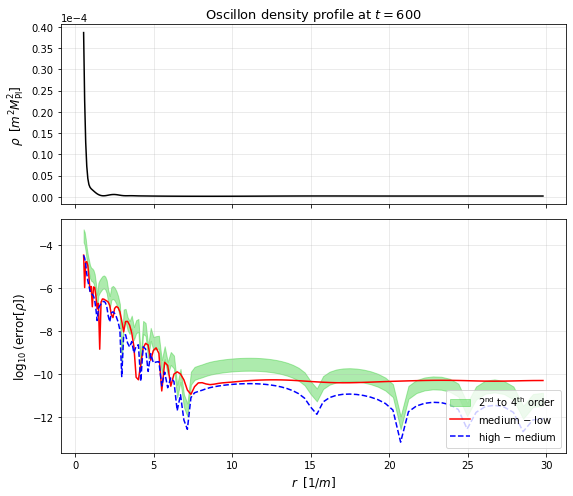


Resolution:  LR dr=0.25,  MR dr=0.125,  HR dr=0.0625
Refinement ratio  h_LR/h_MR = 2,  h_MR/h_HR = 2


In [12]:
# ── Spatial convergence of rho(r) — reproducing paper Fig. C.1 ──

# Choose a snapshot time (late enough that the oscillon has formed).
# Adjust t_snapshot to a time where rho_c has stabilised.
t_snapshot = 600.0
idx_snap = np.argmin(np.abs(t - t_snapshot))
print(f"Snapshot at t = {t[idx_snap]:.1f}  (index {idx_snap})")

# Extract rho(r) at the snapshot for each resolution
rho_snap_LR = osc_LR["rho"][idx_snap]
rho_snap_MR = osc_MR["rho"][idx_snap]
rho_snap_HR = osc_HR["rho"][idx_snap]

# Interpolate LR and MR profiles onto the HR grid for pointwise comparison
from scipy.interpolate import interp1d

rho_LR_on_HR = interp1d(r_LR, rho_snap_LR, kind='cubic',
                         fill_value='extrapolate')(r_HR)
rho_MR_on_HR = interp1d(r_MR, rho_snap_MR, kind='cubic',
                         fill_value='extrapolate')(r_HR)
rho_HR_on_HR = rho_snap_HR

# Differences
diff_ML = np.abs(rho_MR_on_HR - rho_LR_on_HR)   # "medium – low"
diff_HM = np.abs(rho_HR_on_HR - rho_MR_on_HR)    # "high – medium"

# Restrict to the inner region where the oscillon lives
r_plot_max = 30.0
pmask = (r_HR > 0.5) & (r_HR < r_plot_max)

# ── Two-panel figure matching Fig. C.1 ──
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(8, 7),
                                      sharex=True,
                                      gridspec_kw={'height_ratios': [1, 1.3]})

# Top panel: density profile at HR
ax_top.plot(r_HR[pmask], rho_HR_on_HR[pmask], 'k-', lw=1.5)
ax_top.set_ylabel(r'$\rho \;\;[m^2 M_{\rm Pl}^2]$', fontsize=12)
ax_top.set_title(rf'Oscillon density profile at $t = {t[idx_snap]:.0f}$',
                 fontsize=13)
ax_top.ticklabel_format(axis='y', style='sci', scilimits=(-4,-4))
ax_top.grid(True, alpha=0.3)

# Bottom panel: log(error) with 2nd-to-4th order band
floor = 1e-30
log_diff_ML = np.log10(np.maximum(diff_ML[pmask], floor))
log_diff_HM = np.log10(np.maximum(diff_HM[pmask], floor))

# Rescale high–medium by 2^p for p = 2 (factor 4) and p = 4 (factor 16)
log_HM_2nd = np.log10(np.maximum(4  * diff_HM[pmask], floor))
log_HM_4th = np.log10(np.maximum(16 * diff_HM[pmask], floor))

ax_bot.fill_between(r_HR[pmask], log_HM_2nd, log_HM_4th,
                    color='limegreen', alpha=0.4,
                    label=r'$2^{\rm nd}$ to $4^{\rm th}$ order')
ax_bot.plot(r_HR[pmask], log_diff_ML, 'r-',  lw=1.5,
            label='medium $-$ low')
ax_bot.plot(r_HR[pmask], log_diff_HM, 'b--', lw=1.5,
            label='high $-$ medium')

ax_bot.set_xlabel(r'$r \;\;[1/m]$', fontsize=12)
ax_bot.set_ylabel(r'$\log_{10}({\rm error}[\rho])$', fontsize=12)
ax_bot.legend(fontsize=10, loc='lower right')
ax_bot.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

print(f"\nResolution:  LR dr={min_dr_LR},  MR dr={min_dr_MR},  HR dr={min_dr_HR}")
print(f"Refinement ratio  h_LR/h_MR = {min_dr_LR/min_dr_MR:.0f},  "
      f"h_MR/h_HR = {min_dr_MR/min_dr_HR:.0f}")